# 🧠 Student Social Media & Mental Health Impact
### End-to-End Machine Learning Analysis

This notebook walks through a **complete data science workflow**:

1. **Data Loading & First Look** — load the CSV, understand shape and columns
2. **Preprocessing** — check nulls, duplicates, data types
3. **Exploratory Data Analysis (EDA)** — visualise distributions and relationships
4. **Feature Engineering** — encode categories, build preprocessing pipelines
5. **Model Training** — train and compare **6 regression models**
6. **Model Evaluation** — R², MAE, RMSE side-by-side
7. **Cross-Validation** — 5-fold CV for robust comparison
8. **Best Model Deep-Dive** — feature importance, residuals, actual vs predicted
9. **Save Final Model** for **Streamlit Deployment**

**Target variable:** `Mental_Health_Score` (continuous, range 3.6 – 9.4)

## 1. Import Libraries

We import everything up front — data handling, visualisation, and the six scikit-learn models we will compare.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Preprocessing & Pipelines ──────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# ── Six Regression Models ──────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor,
                               GradientBoostingRegressor,
                               ExtraTreesRegressor)

# ── Evaluation Metrics ─────────────────────────────────────────────
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ── Plot style ─────────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load the Dataset

We read the CSV file into a pandas DataFrame. The dataset contains **5,000 student records** and **13 columns**.

In [2]:
df = pd.read_csv(
    "C:\DataScience\Mental_Health_Score_AI\Student Social Media And Mental Health Impact.csv"
)

In [3]:
df

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


## 3. Preprocessing :

#### Before analysing or modelling, we must understand and clean the data.

### 3.1 First Five Rows
A quick glance at the data to confirm it loaded correctly.

In [4]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


### 3.2 Last Five Rows
Checking the tail ensures there is no junk at the end of the file.

In [5]:
df.tail()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7
4999,19,Male,China,Undergraduate,WeChat,Entertainment,5.4,177,1.2,1.5,6.3,High,6.1


### 3.3 Shape of the Dataset
Rows × Columns.

In [6]:
df.shape

(5000, 13)

### 3.4 All Column Names

In [7]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

### 3.5 Data Types of Each Column
`object` / `str` columns are categorical text; everything else is numeric.

In [8]:
df.dtypes

Age                          int64
Gender                      object
Country                     object
Academic_Level              object
Most_Used_Platform          object
Purpose_Of_Use              object
Avg_Daily_Usage_Hours      float64
Daily_Unlocks                int64
Study_Hours                float64
Physical_Activity_Hours    float64
Sleep_Hours_Per_Night      float64
Stress_Level                object
Mental_Health_Score        float64
dtype: object

### 3.6 Detailed Info
`df.info()` shows data types, non-null counts, and memory usage at a glance.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


### 3.7 Check for Null / Missing Values
Ideally we want 0 nulls everywhere. If any exist, the preprocessing pipeline will handle them.

In [10]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [11]:
df.isnull().sum()/len(df)*100

Age                        0.0
Gender                     0.0
Country                    0.0
Academic_Level             0.0
Most_Used_Platform         0.0
Purpose_Of_Use             0.0
Avg_Daily_Usage_Hours      0.0
Daily_Unlocks              0.0
Study_Hours                0.0
Physical_Activity_Hours    0.0
Sleep_Hours_Per_Night      0.0
Stress_Level               0.0
Mental_Health_Score        0.0
dtype: float64

### 3.8 Check for Duplicate Rows
Duplicates can bias model training. We drop them if found.

In [12]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

In [13]:
df.duplicated().sum()

np.int64(2)

### 3.9 Statistical Summary
`describe()` gives count, mean, std, min, quartiles, and max for every numeric column. Useful for spotting outliers.

In [14]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [15]:
df.describe().round()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0
mean,21.0,5.0,171.0,3.0,2.0,7.0,6.0
std,2.0,2.0,43.0,2.0,1.0,1.0,1.0
min,18.0,1.0,62.0,0.0,-0.0,4.0,4.0
25%,19.0,4.0,140.0,2.0,1.0,6.0,5.0
50%,21.0,5.0,171.0,3.0,2.0,7.0,6.0
75%,22.0,6.0,204.0,4.0,2.0,8.0,7.0
max,24.0,9.0,273.0,8.0,4.0,10.0,9.0


### 3.10 Unique Values from Categorical Columns Academic_Level
Understand distinct categories before encoding.

In [16]:
df['Academic_Level'].unique()

array(['Undergraduate', 'Graduate', 'High School'], dtype=object)

In [17]:
df['Academic_Level'].nunique()

3

In [18]:
df['Most_Used_Platform'].unique()

array(['Facebook', 'LinkedIn', 'Instagram', 'Snapchat', 'Twitter',
       'YouTube', 'TikTok', 'LINE', 'KakaoTalk', 'VKontakte', 'WhatsApp',
       'WeChat'], dtype=object)

In [19]:
df['Most_Used_Platform'].nunique()

12

In [20]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

In [21]:
df['Stress_Level'].nunique()

4

In [22]:
df['Purpose_Of_Use'].unique()

array(['Networking', 'Education', 'Entertainment', 'News'], dtype=object)

In [23]:
df['Purpose_Of_Use'].nunique()

4

In [24]:
df[df['Age']>0]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


In [25]:
df[df['Avg_Daily_Usage_Hours']>0]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


In [26]:
df[df['Avg_Daily_Usage_Hours']<1.5]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
2410,23,Female,Other,Graduate,LinkedIn,Education,1.0,73,6.7,2.3,8.8,Low,7.6
3219,18,Male,Other,High School,Snapchat,Entertainment,1.2,86,6.1,2.3,8.3,Low,7.3
3236,24,Male,Other,Graduate,Snapchat,Entertainment,1.4,68,5.8,3.0,9.1,Low,7.5
3523,24,Female,Canada,Graduate,YouTube,Education,1.4,89,5.7,1.7,7.2,Medium,7.4
3626,23,Male,Other,Graduate,YouTube,Education,1.3,79,6.1,3.0,7.2,Low,8.0
3649,19,Female,USA,Undergraduate,Instagram,Entertainment,1.2,70,6.4,3.2,8.0,Low,8.2
3926,24,Male,Other,Graduate,Snapchat,Entertainment,1.4,68,5.9,2.9,9.1,Low,7.2
4016,23,Female,India,Graduate,Snapchat,Entertainment,1.1,74,5.7,3.0,7.3,Low,7.2
4085,23,Female,Other,Graduate,LinkedIn,Education,1.4,73,7.1,2.5,8.7,Low,7.6
4393,22,Male,Australia,Undergraduate,Instagram,Entertainment,1.3,71,6.5,2.3,8.8,Low,8.9


In [27]:
df[df['Daily_Unlocks']>250]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
40,24,Male,Other,Graduate,Twitter,News,8.3,259,1.0,1.3,5.5,Very High,4.3
43,20,Male,Other,Undergraduate,TikTok,Entertainment,8.1,256,1.0,1.7,4.5,Very High,5.7
51,19,Female,Other,Undergraduate,Twitter,News,7.9,258,1.0,1.3,5.0,Very High,4.9
67,24,Female,Other,Graduate,Instagram,Entertainment,8.2,251,1.0,1.0,5.3,Very High,4.4
85,19,Male,India,Undergraduate,Instagram,Entertainment,8.1,259,1.0,0.8,4.8,Very High,4.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4802,18,Female,Other,High School,Twitter,News,8.2,257,0.9,0.8,5.6,Very High,5.6
4835,19,Female,Other,Undergraduate,Snapchat,Entertainment,8.0,254,2.2,2.0,5.7,Very High,5.4
4915,24,Male,India,Graduate,Instagram,Entertainment,8.5,269,0.6,1.1,4.8,Very High,4.2
4927,23,Female,Germany,Graduate,Instagram,Entertainment,8.0,253,1.0,1.0,5.6,Very High,4.9


In [28]:
df[df['Study_Hours']>4.0]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
5,19,Female,Other,Undergraduate,Twitter,News,4.1,138,4.6,2.2,6.8,Low,6.8
10,18,Male,Other,High School,LinkedIn,Education,4.1,133,4.3,1.8,7.3,High,6.8
12,20,Male,Other,Undergraduate,Facebook,Networking,2.4,86,6.2,1.8,8.8,Low,8.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4985,19,Female,Switzerland,Undergraduate,Instagram,Entertainment,2.3,107,5.1,3.1,9.5,Low,8.2
4987,21,Male,Pakistan,Undergraduate,Instagram,Entertainment,4.1,145,4.5,1.9,7.9,Medium,5.1
4993,19,Female,Japan,Undergraduate,LINE,News,2.9,114,6.2,2.0,8.4,Medium,7.9
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9


In [29]:
df[df['Study_Hours']<4.0]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
6,22,Female,Other,Undergraduate,Instagram,Entertainment,8.0,246,1.0,0.9,5.2,Very High,5.3
7,21,Female,Other,Undergraduate,Facebook,Networking,6.0,209,1.0,1.3,5.7,High,4.7
8,24,Male,USA,Graduate,YouTube,Education,4.7,154,2.4,1.1,7.0,High,6.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4991,23,Female,Other,Graduate,TikTok,Entertainment,6.2,213,1.4,1.0,6.1,Very High,4.3
4992,18,Male,UK,High School,Snapchat,Entertainment,6.4,215,1.4,2.0,5.9,High,5.6
4994,20,Female,Paraguay,Undergraduate,TikTok,Entertainment,4.6,178,3.2,2.1,5.9,Medium,5.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7


In [30]:
df[df['Physical_Activity_Hours']>3.0]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
103,18,Male,Other,High School,Snapchat,Entertainment,3.7,144,5.0,3.5,7.5,Low,7.0
117,20,Male,India,Undergraduate,Instagram,Entertainment,3.8,122,5.2,3.1,8.2,High,7.8
125,21,Female,Other,Undergraduate,Facebook,Networking,3.6,115,3.3,3.1,7.2,Medium,9.0
150,18,Male,Other,High School,Twitter,News,1.8,98,5.8,3.4,8.0,Low,8.0
177,18,Male,Other,High School,Snapchat,Entertainment,1.6,65,5.7,3.2,8.1,Low,8.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4940,20,Male,Tajikistan,Undergraduate,YouTube,Education,4.5,151,1.4,3.4,5.7,High,5.9
4945,22,Female,Other,Undergraduate,Snapchat,Entertainment,2.1,94,6.2,3.3,8.1,Low,7.6
4949,22,Male,Denmark,Undergraduate,Facebook,Networking,3.3,110,5.7,3.4,9.0,Medium,7.9
4956,20,Male,Other,Undergraduate,TikTok,Entertainment,3.6,141,3.3,3.6,7.5,Low,8.3


In [31]:
df[df['Physical_Activity_Hours']<1.0]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
6,22,Female,Other,Undergraduate,Instagram,Entertainment,8.0,246,1.0,0.9,5.2,Very High,5.3
15,18,Female,Other,High School,Twitter,News,5.2,155,3.3,0.6,7.0,High,6.3
16,22,Female,USA,Undergraduate,YouTube,Education,6.5,226,1.3,0.9,5.4,Very High,5.0
35,18,Male,UK,High School,Instagram,Entertainment,6.8,219,1.5,0.4,5.5,Very High,4.2
38,22,Male,USA,Undergraduate,LinkedIn,Education,5.7,204,3.3,0.7,6.8,Medium,6.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4918,24,Female,Other,Graduate,YouTube,Education,7.2,246,1.0,0.5,5.9,Very High,5.2
4929,19,Female,UAE,Undergraduate,Instagram,Entertainment,6.6,185,2.8,0.8,5.4,Very High,5.3
4950,22,Male,Other,Undergraduate,Facebook,Networking,7.9,250,1.1,0.5,5.1,Very High,5.8
4957,19,Female,USA,Undergraduate,TikTok,Entertainment,6.8,215,1.9,0.5,5.2,Very High,3.8


In [32]:
df[df['Sleep_Hours_Per_Night']>9.0]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
1444,19,Female,Switzerland,Undergraduate,Instagram,Entertainment,2.7,129,5.3,2.5,9.1,Low,8.0
1451,22,Male,Denmark,Undergraduate,Facebook,Networking,2.7,126,4.0,2.5,9.1,Low,8.0
1454,20,Female,Switzerland,Undergraduate,Instagram,Entertainment,2.6,123,6.4,2.3,9.2,Medium,8.0
1461,21,Male,Denmark,Undergraduate,Facebook,Networking,2.6,129,5.1,1.9,9.2,Medium,8.0
1464,19,Female,Switzerland,Undergraduate,Instagram,Entertainment,2.5,126,5.4,1.7,9.3,Low,8.0
1471,22,Male,Denmark,Undergraduate,Facebook,Networking,2.5,114,7.1,2.6,9.3,Low,8.0
1474,20,Female,Switzerland,Undergraduate,Instagram,Entertainment,2.4,87,4.3,2.2,9.4,Low,8.0
1481,21,Male,Denmark,Undergraduate,Facebook,Networking,2.4,116,6.7,2.3,9.4,Low,8.0
1484,19,Female,Switzerland,Undergraduate,Instagram,Entertainment,2.3,107,5.1,2.9,9.5,Low,8.0
1488,19,Female,France,Undergraduate,Instagram,Entertainment,2.9,132,4.5,1.7,9.1,Low,7.0


In [33]:
df[df['Sleep_Hours_Per_Night']<4.0]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
1486,20,Female,USA,Undergraduate,TikTok,Entertainment,8.4,270,1.0,1.2,3.9,Very High,5.0
1496,19,Female,USA,Undergraduate,Instagram,Entertainment,8.5,257,1.0,0.5,3.8,Very High,5.0
1906,19,Female,USA,Undergraduate,Instagram,Entertainment,8.5,267,1.0,0.4,3.8,Very High,5.0
2189,19,Female,USA,Undergraduate,Instagram,Entertainment,8.8,257,1.1,0.2,3.6,Very High,5.0
3244,20,Female,USA,Undergraduate,TikTok,Entertainment,8.3,270,1.3,1.5,3.7,Very High,5.2
3965,19,Female,USA,Undergraduate,Instagram,Entertainment,8.6,257,1.3,0.3,3.7,Very High,5.3
4383,19,Female,USA,Undergraduate,Instagram,Entertainment,8.5,267,0.7,0.6,3.8,Very High,5.1
4394,20,Female,Nepal,Undergraduate,TikTok,Entertainment,6.0,188,2.0,1.1,3.7,Very High,5.9


In [34]:
df[df['Mental_Health_Score']>9.0]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
2120,23,Male,Other,Graduate,Instagram,Entertainment,3.2,133,5.2,2.8,9.0,Low,9.4
2265,22,Male,Other,Undergraduate,YouTube,Education,3.8,141,4.7,1.4,7.5,Medium,9.1
2293,21,Male,Other,Undergraduate,TikTok,Entertainment,2.6,119,4.9,1.8,7.4,High,9.1
2304,22,Female,Other,Undergraduate,YouTube,Education,2.3,111,4.9,1.8,9.0,Low,9.1
2535,19,Male,Other,Undergraduate,Snapchat,Entertainment,2.6,97,6.8,2.7,7.9,Low,9.2
2556,21,Female,Other,Undergraduate,Facebook,Networking,3.9,115,3.3,3.5,7.3,Medium,9.2
2676,21,Male,Other,Undergraduate,TikTok,Entertainment,2.4,115,3.6,1.9,7.1,Low,9.2
2738,18,Female,Other,High School,TikTok,Entertainment,3.2,116,3.6,2.2,8.6,Low,9.2
2786,19,Male,Other,Undergraduate,Snapchat,Entertainment,2.6,97,6.7,2.5,7.9,Low,9.1
2867,22,Female,Other,Undergraduate,YouTube,Education,2.2,84,6.3,2.6,9.2,Low,9.1


In [35]:
df[df['Mental_Health_Score']<4.0]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
2098,20,Female,USA,Undergraduate,LinkedIn,Education,7.3,216,0.7,1.4,6.0,Very High,3.9
2152,21,Female,Other,Undergraduate,YouTube,Education,5.6,177,2.2,2.5,4.6,Very High,3.9
2313,18,Male,India,High School,Instagram,Entertainment,7.0,195,0.7,1.4,4.1,Very High,3.8
2339,18,Male,UK,High School,LinkedIn,Education,7.1,245,1.0,1.3,5.6,Very High,3.7
2348,18,Male,Other,High School,LinkedIn,Education,7.2,216,0.8,1.1,5.1,Very High,3.7
2390,23,Male,Australia,Graduate,Snapchat,Entertainment,8.1,228,1.2,1.1,6.1,Very High,3.9
2401,18,Female,Czech Republic,High School,Snapchat,Entertainment,5.9,195,3.2,1.6,5.2,Very High,3.8
2418,24,Female,Other,Graduate,Snapchat,Entertainment,6.6,193,1.9,1.4,4.7,Very High,3.9
2460,21,Male,India,Undergraduate,Facebook,Networking,7.5,221,1.2,1.3,5.6,Very High,3.9
2805,19,Female,USA,Undergraduate,Instagram,Entertainment,6.9,213,1.9,0.6,5.4,Very High,3.8


In [36]:
df[df['Academic_Level'] =="High School"]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
10,18,Male,Other,High School,LinkedIn,Education,4.1,133,4.3,1.8,7.3,High,6.8
11,18,Male,Other,High School,Snapchat,Entertainment,7.6,240,1.0,1.1,5.3,Very High,5.5
15,18,Female,Other,High School,Twitter,News,5.2,155,3.3,0.6,7.0,High,6.3
35,18,Male,UK,High School,Instagram,Entertainment,6.8,219,1.5,0.4,5.5,Very High,4.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4964,18,Female,Other,High School,LinkedIn,Education,5.9,188,2.8,1.3,6.0,High,4.9
4992,18,Male,UK,High School,Snapchat,Entertainment,6.4,215,1.4,2.0,5.9,High,5.6
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7


In [37]:
df[df['Academic_Level']=='Undergraduate']

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
5,19,Female,Other,Undergraduate,Twitter,News,4.1,138,4.6,2.2,6.8,Low,6.8
6,22,Female,Other,Undergraduate,Instagram,Entertainment,8.0,246,1.0,0.9,5.2,Very High,5.3
7,21,Female,Other,Undergraduate,Facebook,Networking,6.0,209,1.0,1.3,5.7,High,4.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4990,21,Male,Mexico,Undergraduate,WhatsApp,Education,7.0,222,0.8,1.2,5.2,Very High,6.2
4993,19,Female,Japan,Undergraduate,LINE,News,2.9,114,6.2,2.0,8.4,Medium,7.9
4994,20,Female,Paraguay,Undergraduate,TikTok,Entertainment,4.6,178,3.2,2.1,5.9,Medium,5.9
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0


In [38]:
df[df['Most_Used_Platform']=='Facebook']

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
7,21,Female,Other,Undergraduate,Facebook,Networking,6.0,209,1.0,1.3,5.7,High,4.7
12,20,Male,Other,Undergraduate,Facebook,Networking,2.4,86,6.2,1.8,8.8,Low,8.5
18,21,Male,Canada,Undergraduate,Facebook,Networking,6.9,212,1.0,1.5,5.9,High,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4950,22,Male,Other,Undergraduate,Facebook,Networking,7.9,250,1.1,0.5,5.1,Very High,5.8
4953,21,Male,India,Undergraduate,Facebook,Networking,4.6,181,4.0,1.6,8.3,Medium,6.8
4969,23,Male,Spain,Graduate,Facebook,Networking,6.9,193,1.0,1.2,6.1,Very High,4.7
4973,20,Male,Other,Undergraduate,Facebook,Networking,4.8,149,2.6,1.7,7.6,Medium,5.6


In [39]:
df[df['Most_Used_Platform']=='Instagram']

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
6,22,Female,Other,Undergraduate,Instagram,Entertainment,8.0,246,1.0,0.9,5.2,Very High,5.3
14,24,Male,India,Graduate,Instagram,Entertainment,2.7,120,5.4,2.4,8.6,Medium,7.8
19,20,Male,Other,Undergraduate,Instagram,Entertainment,5.5,183,2.2,1.0,6.8,Very High,6.8
25,21,Male,Other,Undergraduate,Instagram,Entertainment,6.2,208,2.2,1.1,4.7,Very High,5.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4983,22,Male,Other,Undergraduate,Instagram,Entertainment,5.6,199,2.6,1.7,5.6,High,4.9
4985,19,Female,Switzerland,Undergraduate,Instagram,Entertainment,2.3,107,5.1,3.1,9.5,Low,8.2
4987,21,Male,Pakistan,Undergraduate,Instagram,Entertainment,4.1,145,4.5,1.9,7.9,Medium,5.1
4989,19,Female,USA,Undergraduate,Instagram,Entertainment,6.9,230,2.4,1.8,6.2,Very High,3.8


In [40]:
df[df['Stress_Level']=='Very High']

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
6,22,Female,Other,Undergraduate,Instagram,Entertainment,8.0,246,1.0,0.9,5.2,Very High,5.3
11,18,Male,Other,High School,Snapchat,Entertainment,7.6,240,1.0,1.1,5.3,Very High,5.5
13,23,Female,Other,Graduate,LinkedIn,Education,6.2,189,1.5,1.4,5.3,Very High,5.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4988,22,Female,Other,Undergraduate,TikTok,Entertainment,7.3,215,0.9,1.8,4.9,Very High,5.6
4989,19,Female,USA,Undergraduate,Instagram,Entertainment,6.9,230,2.4,1.8,6.2,Very High,3.8
4990,21,Male,Mexico,Undergraduate,WhatsApp,Education,7.0,222,0.8,1.2,5.2,Very High,6.2
4991,23,Female,Other,Graduate,TikTok,Entertainment,6.2,213,1.4,1.0,6.1,Very High,4.3


In [41]:
df[df['Stress_Level']=='Low']

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
5,19,Female,Other,Undergraduate,Twitter,News,4.1,138,4.6,2.2,6.8,Low,6.8
12,20,Male,Other,Undergraduate,Facebook,Networking,2.4,86,6.2,1.8,8.8,Low,8.5
20,23,Female,Other,Graduate,Facebook,Networking,2.0,100,5.7,2.6,7.9,Low,7.1
22,24,Male,Other,Graduate,Facebook,Networking,2.0,110,6.4,2.9,7.8,Low,8.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4956,20,Male,Other,Undergraduate,TikTok,Entertainment,3.6,141,3.3,3.6,7.5,Low,8.3
4968,19,Female,Other,Undergraduate,YouTube,Education,3.0,136,5.4,2.9,7.0,Low,9.0
4971,20,Male,Denmark,Undergraduate,Twitter,News,4.5,169,3.6,1.8,7.1,Low,6.7
4985,19,Female,Switzerland,Undergraduate,Instagram,Entertainment,2.3,107,5.1,3.1,9.5,Low,8.2


# 4. EDA(Exploratory Data Analysis):
We create **20 visualisations** to understand the data before modelling. Each chart has a numbered title for easy reference.

In [42]:
def show_fig():
    plt.tight_layout()
    plt.show()

stress_order = ['Low', 'Medium', 'High', 'Very High']
plot_no = 1

### 1.Stress Level Distribution with No. of Students

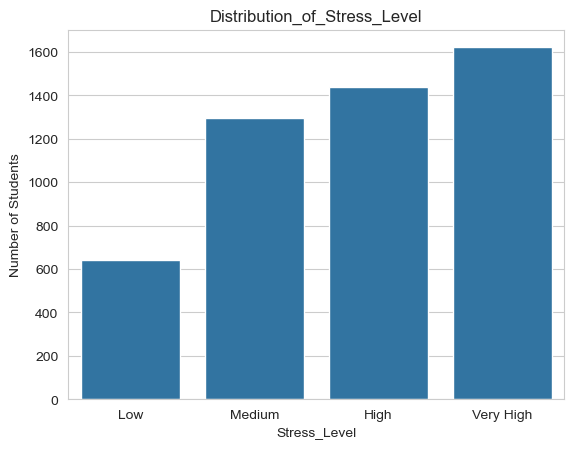

In [43]:
sns.countplot(data=df,x='Stress_Level',order=stress_order)
plt.title('Distribution_of_Stress_Level')
plt.xlabel('Stress_Level')
plt.ylabel('Number of Students')
plt.show();

### 1.1 Stress Level Distribution By Using Pie Chart

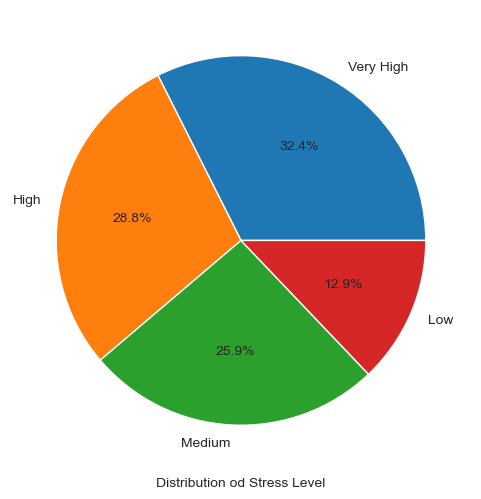

In [44]:
Stress_Level =df['Stress_Level'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(Stress_Level,autopct="%1.1f%%",labels = Stress_Level.index)
plt.xlabel('Distribution od Stress Level')
plt.show();

### 2.Distribution of Most_Used_Platform with No.Of Students

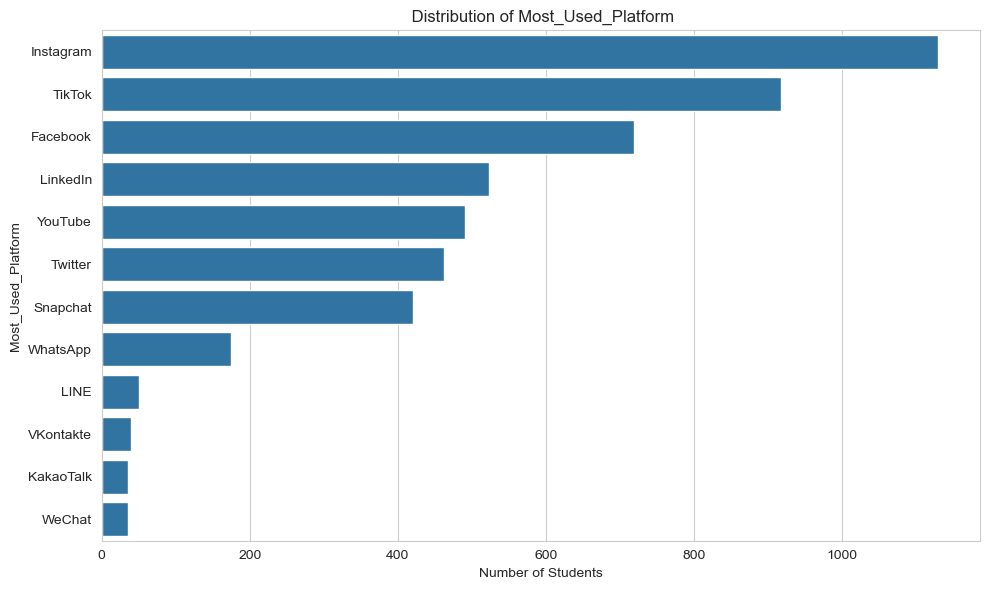

In [45]:
plt.figure(figsize=(10, 6))

counts = df["Most_Used_Platform"].value_counts()

sns.barplot(
    x=counts.values,
    y=counts.index
)

plt.xlabel("Number of Students")
plt.ylabel("Most_Used_Platform")
plt.title(" Distribution of Most_Used_Platform")

plt.tight_layout()
plt.show();

### 3.Distribution of the Target Variable
### A histogram with a KDE curve shows whether Mental_Health_Score is normally distributed or skewed.

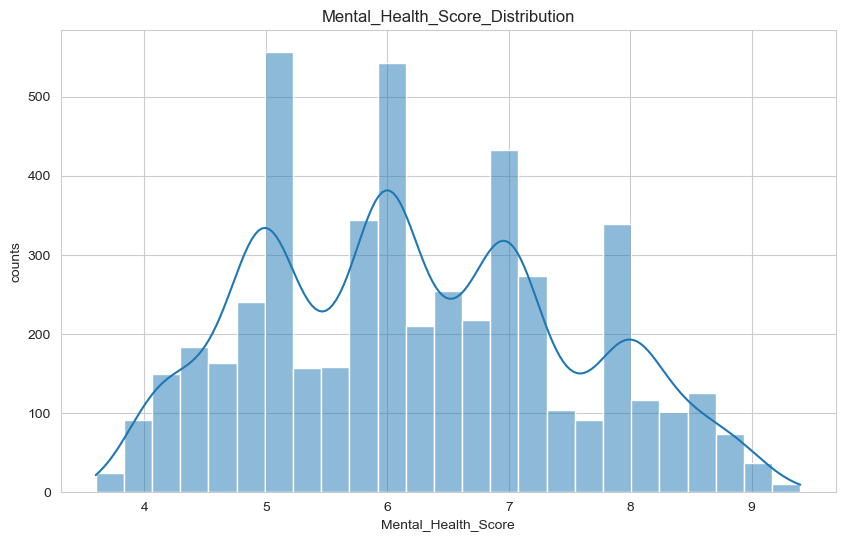

In [46]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Mental_Health_Score'],kde=True)
plt.title('Mental_Health_Score_Distribution')
plt.xlabel('Mental_Health_Score')
plt.ylabel('counts')
plt.show();

### 4.Camparison Effect of Stress_Level vs Mental_Health_Score using boxplot
##### Boxplots show the median, IQR(Inter Quartile Range), and outliers for each stress group. We expect higher stress → lower scores.

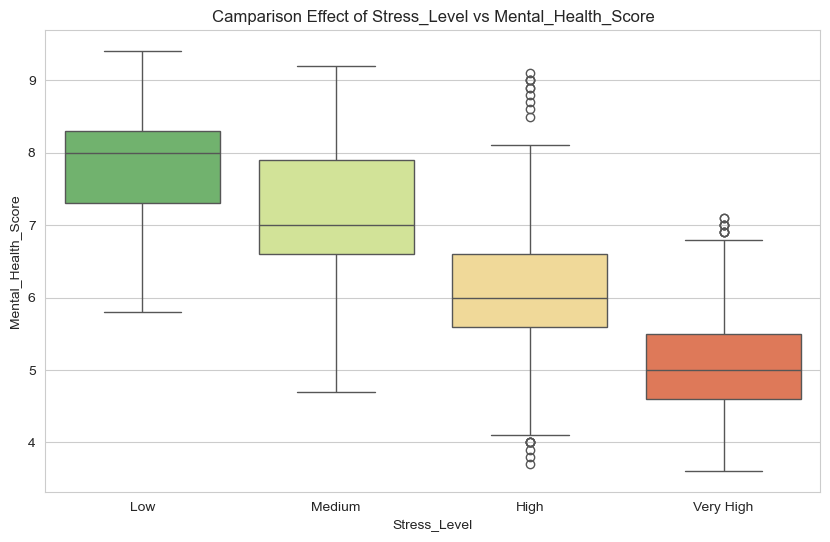

In [47]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Stress_Level',y='Mental_Health_Score',order=stress_order,palette='RdYlGn_r')
plt.xlabel('Stress_Level')
plt.ylabel('Mental_Health_Score')
plt.title('Camparison Effect of Stress_Level vs Mental_Health_Score')
plt.show()

### 5.Daily Social Media Usage vs Mental_Health_Score using Scatter plot
##### (1)hue= Use this column to divide/color the data into groups, 
##### (2)alpha=0.5= is used to control the transparency (opacity) of a plot element and range in bet[0 to 1],
##### (3)palette='RdYlGn_r'= determines which colors are used and colours are Red,Yellow,Green and r for= Reverse it 

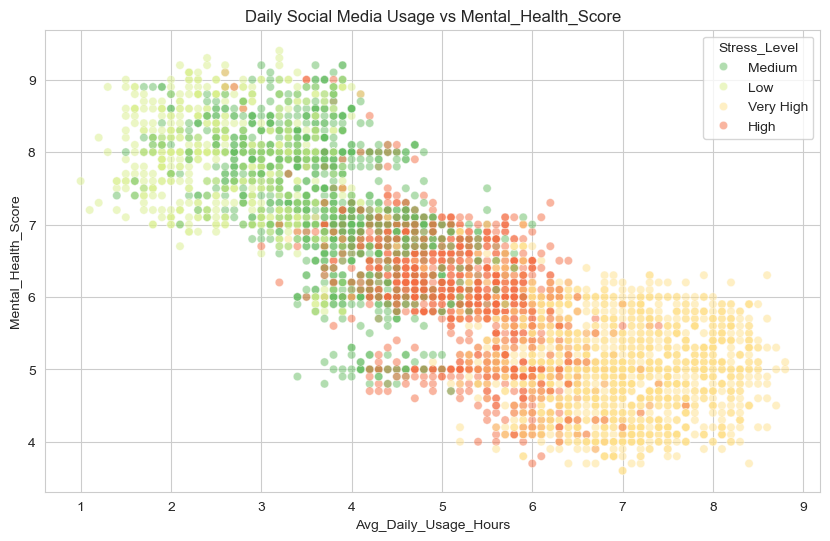

In [48]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Avg_Daily_Usage_Hours', y='Mental_Health_Score',
                hue='Stress_Level', alpha=0.5, palette='RdYlGn_r')
plt.xlabel('Avg_Daily_Usage_Hours')
plt.ylabel('Mental_Health_Score')
plt.title('Daily Social Media Usage vs Mental_Health_Score')
plt.show()

### 6.Physical_Activity_Hours vs Mental_Health_Score using Scatter plot
##### alpha=0.5 = means it is 50% tranperant

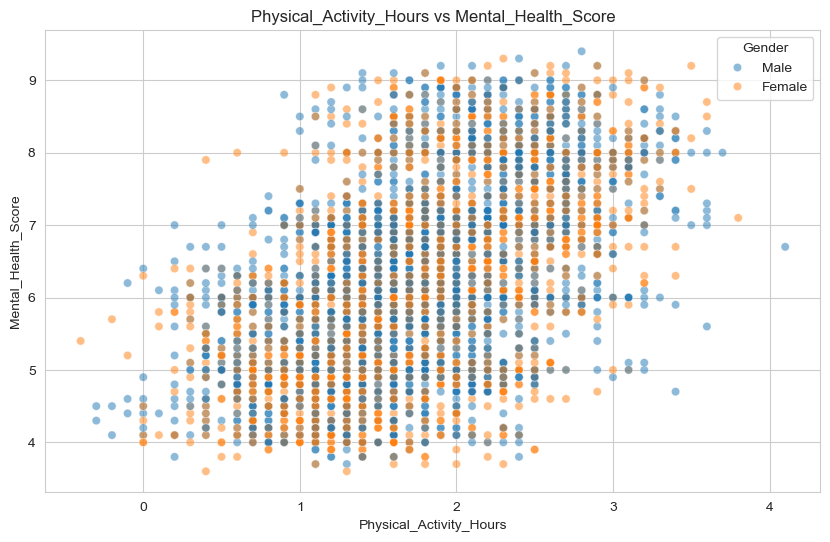

In [49]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Physical_Activity_Hours',y='Mental_Health_Score',
                hue='Gender', alpha=0.5)
plt.xlabel('Physical_Activity_Hours')
plt.ylabel('Mental_Health_Score')
plt.title('Physical_Activity_Hours vs Mental_Health_Score')
plt.show()

### 7.Effect of Sleep_Duration on vs Mental_Health_Score using Scatter plot

More sleep should correlate with better mental health scores.

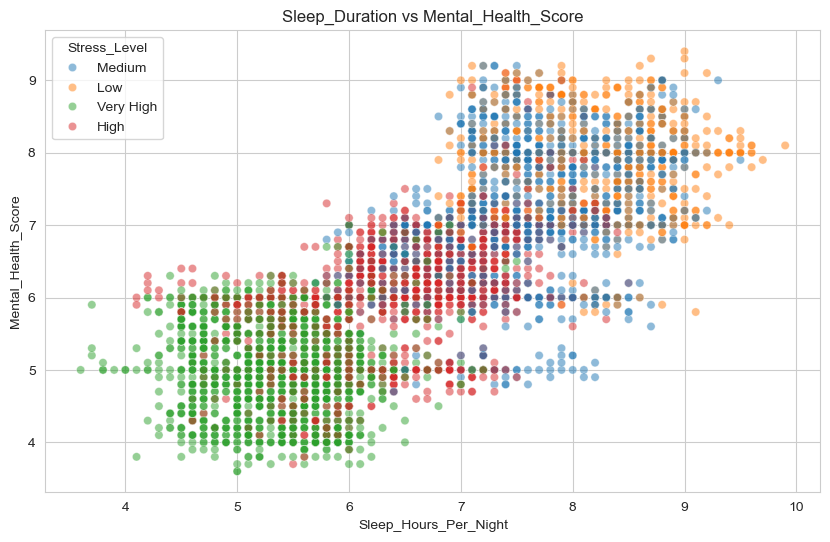

In [50]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Sleep_Hours_Per_Night',y='Mental_Health_Score',hue='Stress_Level',alpha=0.5)
plt.xlabel('Sleep_Hours_Per_Night')
plt.ylabel('Mental_Health_Score')
plt.title('Sleep_Duration vs Mental_Health_Score')
plt.show()

### 8.Study_Hours vs Mental_Health_Score by Academic Level using Scatter plot

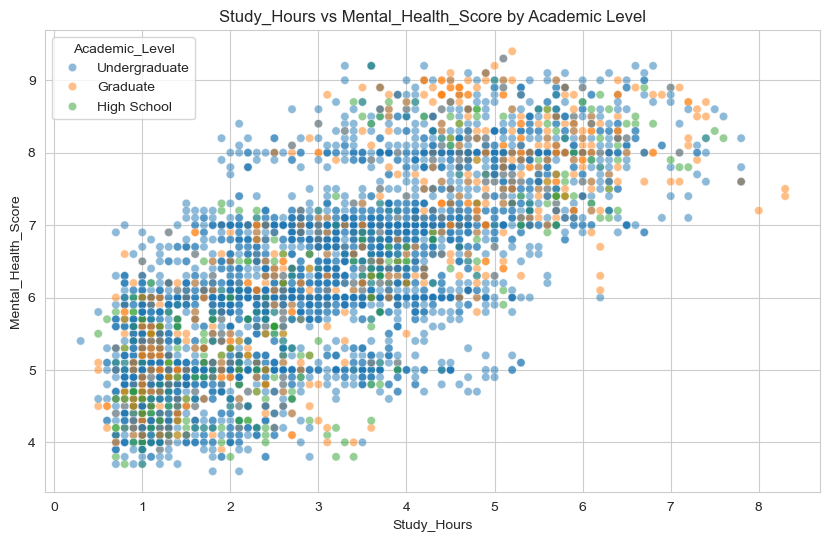

In [51]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Study_Hours',y='Mental_Health_Score',hue='Academic_Level',alpha=0.5)
plt.xlabel('Study_Hours')
plt.ylabel('Mental_Health_Score')
plt.title('Study_Hours vs Mental_Health_Score by Academic Level')
plt.show()

### 9.Mental Health Score By Gender using boxplot
##### palette='Set2'--> It is in-built in seaborn it set's two different colours

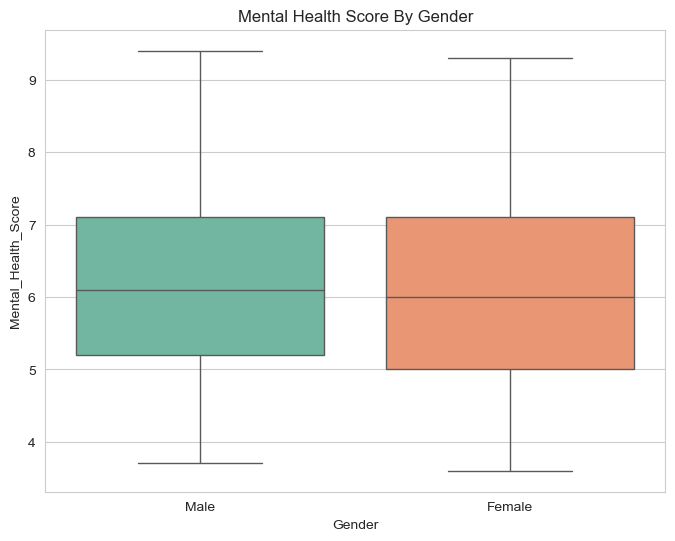

In [52]:
fig=plt.figure(figsize=(8,6))
sns.boxplot(data=df,x='Gender',y='Mental_Health_Score',palette='Set2')
plt.title('Mental Health Score By Gender')
plt.show()

### 10.Mental Health Score By Academic_Level using boxplot

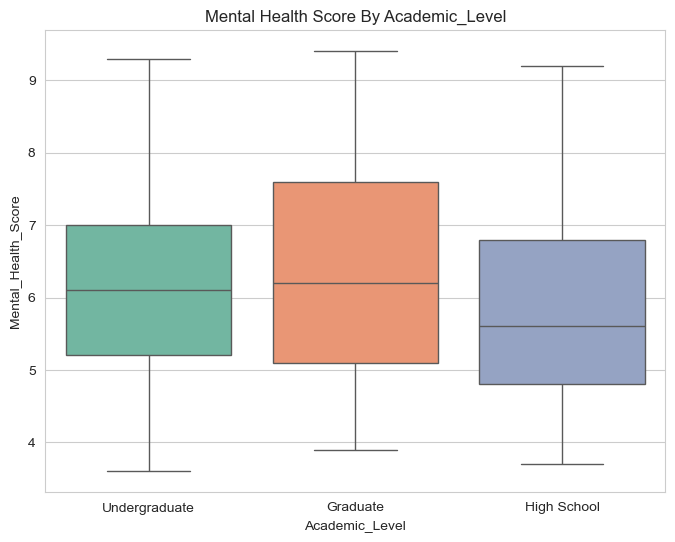

In [53]:
fig=plt.figure(figsize=(8,6))
sns.boxplot(data=df,x='Academic_Level',y='Mental_Health_Score',palette='Set2')
plt.title('Mental Health Score By Academic_Level')
plt.show()

### 11.Distribution_of_Stress_Level using countplot

A simple count to see if the dataset is balanced across stress categories.

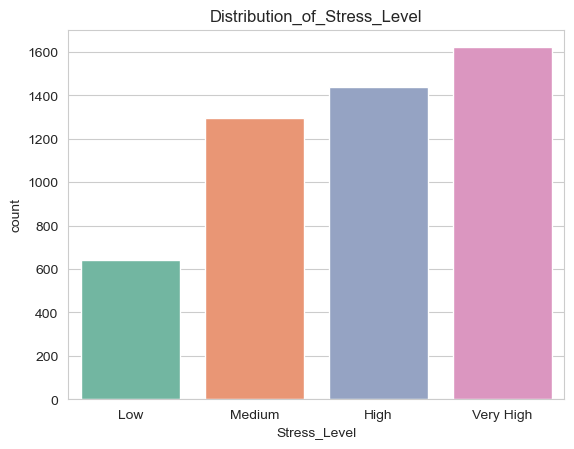

In [54]:
sns.countplot(data=df,x='Stress_Level',order=stress_order,palette='Set2')
plt.title('Distribution_of_Stress_Level')
plt.xlabel('Stress_Level')
plt.show();

### 12.Sleep Pattern Across Stress_Level using violinplot
##### order=stress_order it gives order from low-to-High
##### Violin plots combine a boxplot with a KDE — great for seeing the full shape of each group.

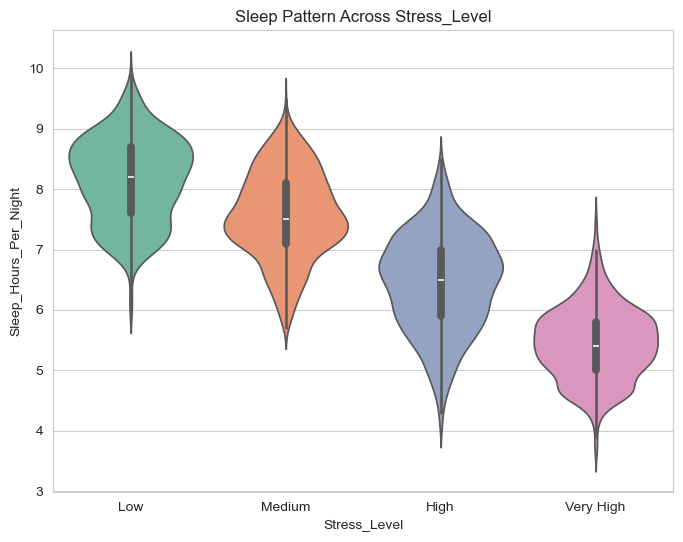

In [55]:
fig = plt.figure(figsize=(8,6))
sns.violinplot(data=df,x='Stress_Level',y='Sleep_Hours_Per_Night',order=stress_order,palette='Set2')
plt.xlabel('Stress_Level')
plt.ylabel('Sleep_Hours_Per_Night')
plt.title('Sleep Pattern Across Stress_Level')
plt.show()

### 13.Mental Health By Preferred Pltform By using Boxplot
##### plt.xticks(rotation=50) = It rotates X-axis values by 50%
##### palette='tab10' = It is in-built seaborn feature which gives 10 different colours

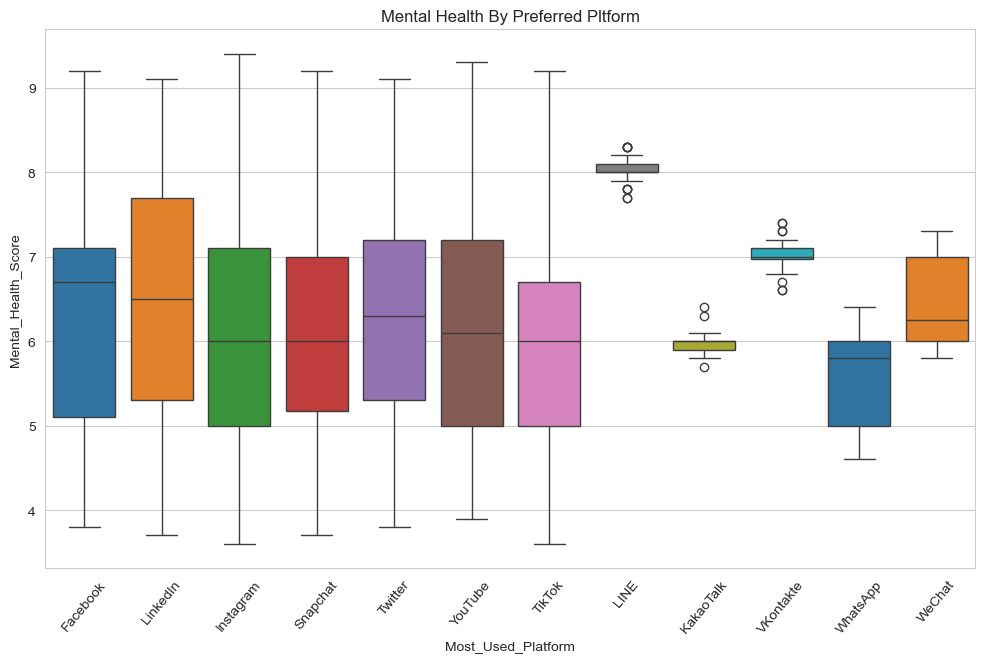

In [56]:
fig = plt.figure(figsize=(12,7))
sns.boxplot(data=df,x='Most_Used_Platform',y='Mental_Health_Score',palette='tab10')
plt.title('Mental Health By Preferred Pltform')
plt.xticks(rotation=50)
plt.show()

### 14.Mental_Health By Purpose of Social Media Use by using Boxplot
##### palette='Set3'--> it set's three different colours in-built feature in seaborn

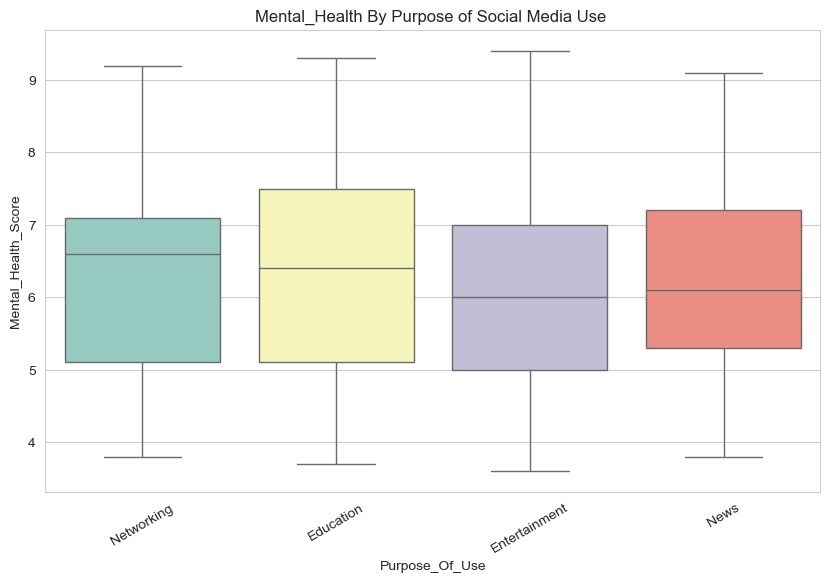

In [57]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Purpose_Of_Use',y='Mental_Health_Score',palette='Set3')
plt.title('Mental_Health By Purpose of Social Media Use ')
plt.xticks(rotation=30)
plt.show()

### 15.Mental_Health_Score Based on Daily_Unlocks by using Scatter plot

Phone unlock frequency is a proxy for phone addiction.

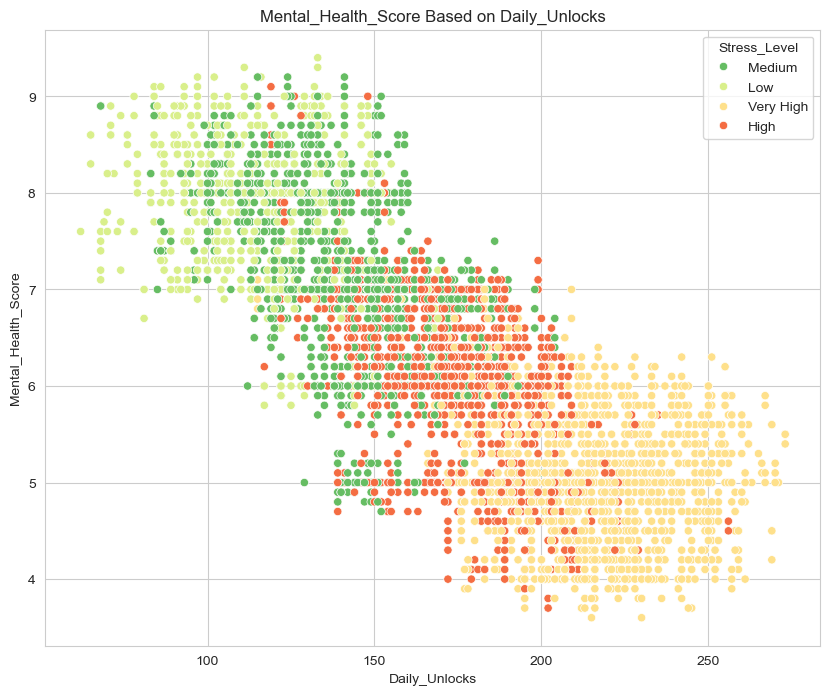

In [58]:
fig = plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x='Daily_Unlocks',y='Mental_Health_Score',hue='Stress_Level',palette='RdYlGn_r')
plt.xlabel('Daily_Unlocks')
plt.ylabel('Mental_Health_Score')
plt.title('Mental_Health_Score Based on Daily_Unlocks')
plt.show()

### 16.Mental_Health_Score Based on Daily Sleep_Hours_Per_Night(Regression Line)
##### `regplot` draws a linear trend with a 95 % confidence band
##### scatter_kws={'alpha':0.3,'s': 30} = As we discussed, alpha controls transparency 30%,scatter_kws means:Scatter-plot keyword arguments and Make the scatter points transparent,'s' : 30 means size of dots

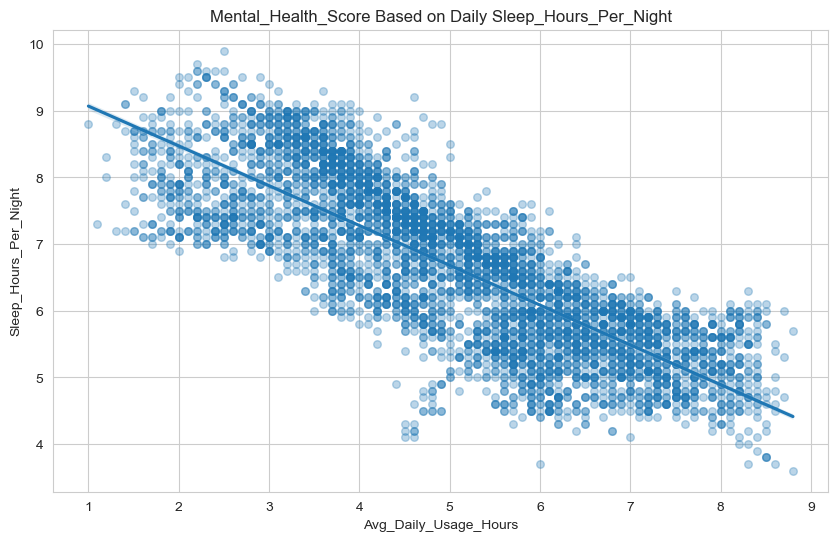

In [59]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df,x='Avg_Daily_Usage_Hours',y='Sleep_Hours_Per_Night',scatter_kws={'alpha':0.3,'s': 30})
plt.xlabel('Avg_Daily_Usage_Hours')
plt.ylabel('Sleep_Hours_Per_Night')
plt.title('Mental_Health_Score Based on Daily Sleep_Hours_Per_Night')
plt.show()

### 17.Stacked Histogram Daily Usage Distribution by Stress Level

#### Stacked histogram: Distribution of values + contribution of different groups
#### A normal histogram shows: How values are distributed.
##### suppose you want to see the distribution of Mental_Health_Score for different Stress_Level groups like              low,Medium,High,Very High
##### multiple = 'stack' = means is a Seaborn histogram parameter. It tells Seaborn how to display multiple groups in the same histogram.

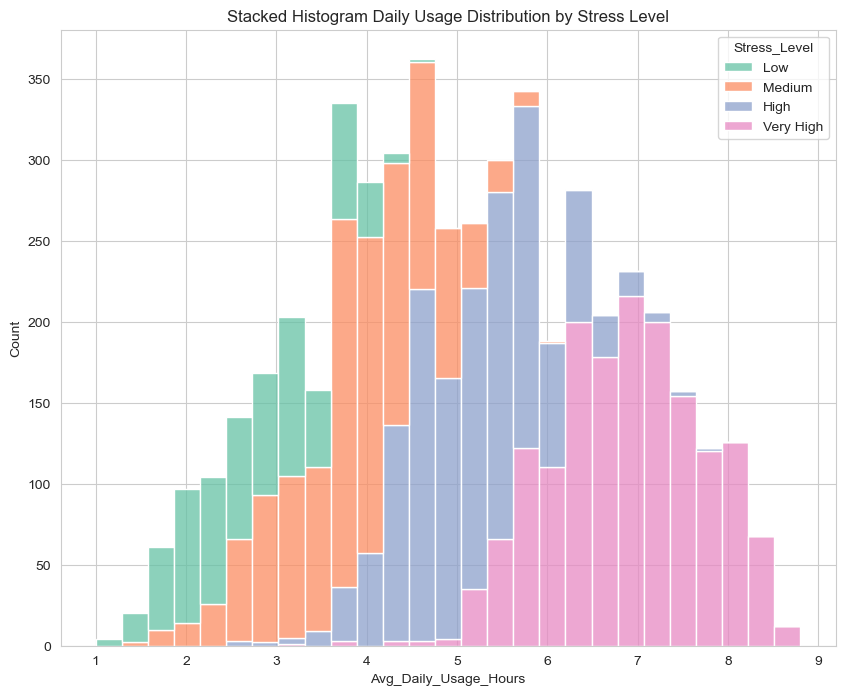

In [60]:
fig = plt.figure(figsize=(10,8))
sns.histplot(data=df,x='Avg_Daily_Usage_Hours',hue='Stress_Level',multiple='stack',palette='Set2',hue_order=stress_order)
plt.title('Stacked Histogram Daily Usage Distribution by Stress Level')
plt.show()

### 18.Sleep Distribution by Stress Level (KDE) Kernal Density Estimation'

##### fill = True means in a KDE plot it is used to fill the area underneath the KDE curve.

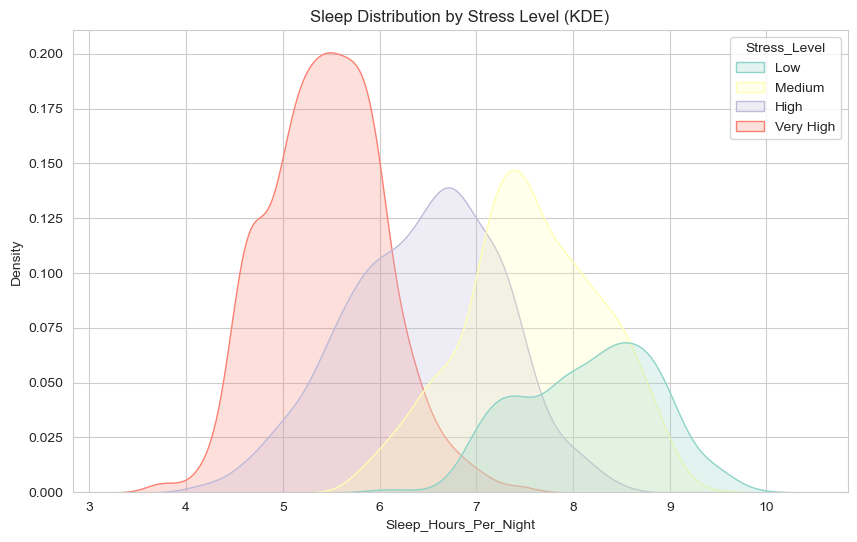

In [61]:
fig = plt.figure(figsize=(10,6))
sns.kdeplot(data=df,x='Sleep_Hours_Per_Night',fill=True,hue='Stress_Level',palette='Set3',hue_order=stress_order)
plt.title('Sleep Distribution by Stress Level (KDE)')
plt.show()

### 19.Correlation HeatMap For Numeric Columns

##### fmt='.2f' = in a Seaborn heatmap controls how the numbers are displayed inside each cell and Show the number as a floating-point value with 2 digits after the decimal point.

##### linewidths=0.5 = in a Seaborn heatmap controls the thickness of the lines/borders between the cells.

Values close to +1 mean two features increase together; close to −1 means they move in opposite directions. Values near 0 mean no linear relationship.

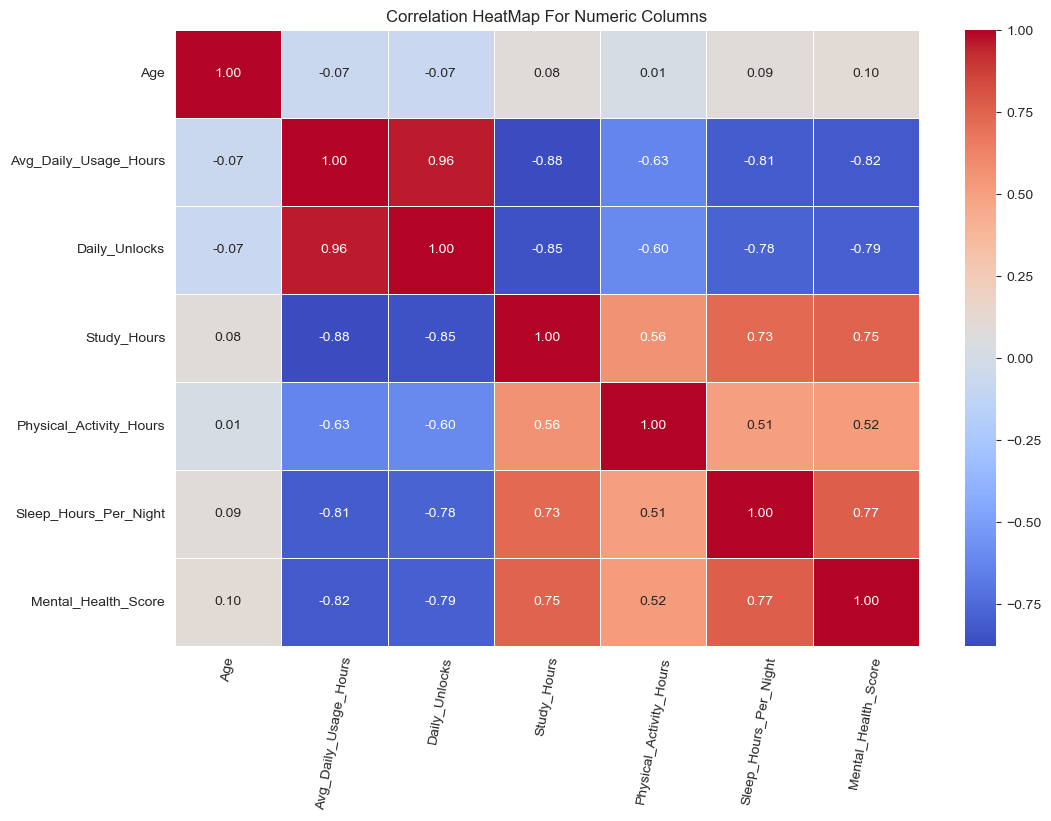

In [62]:
corr = df.select_dtypes(include='number').corr()
fig = plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.5)
plt.title('Correlation HeatMap For Numeric Columns')
plt.xticks(rotation=80)
plt.show()

### 20.Pair Plot of Numeric Features

##### y=1.01 = is usually used with plt.suptitle() to control the vertical position of the overall title.

⏳ This takes a moment — it draws a scatter plot for every numeric pair. Diagonal shows each feature's distribution

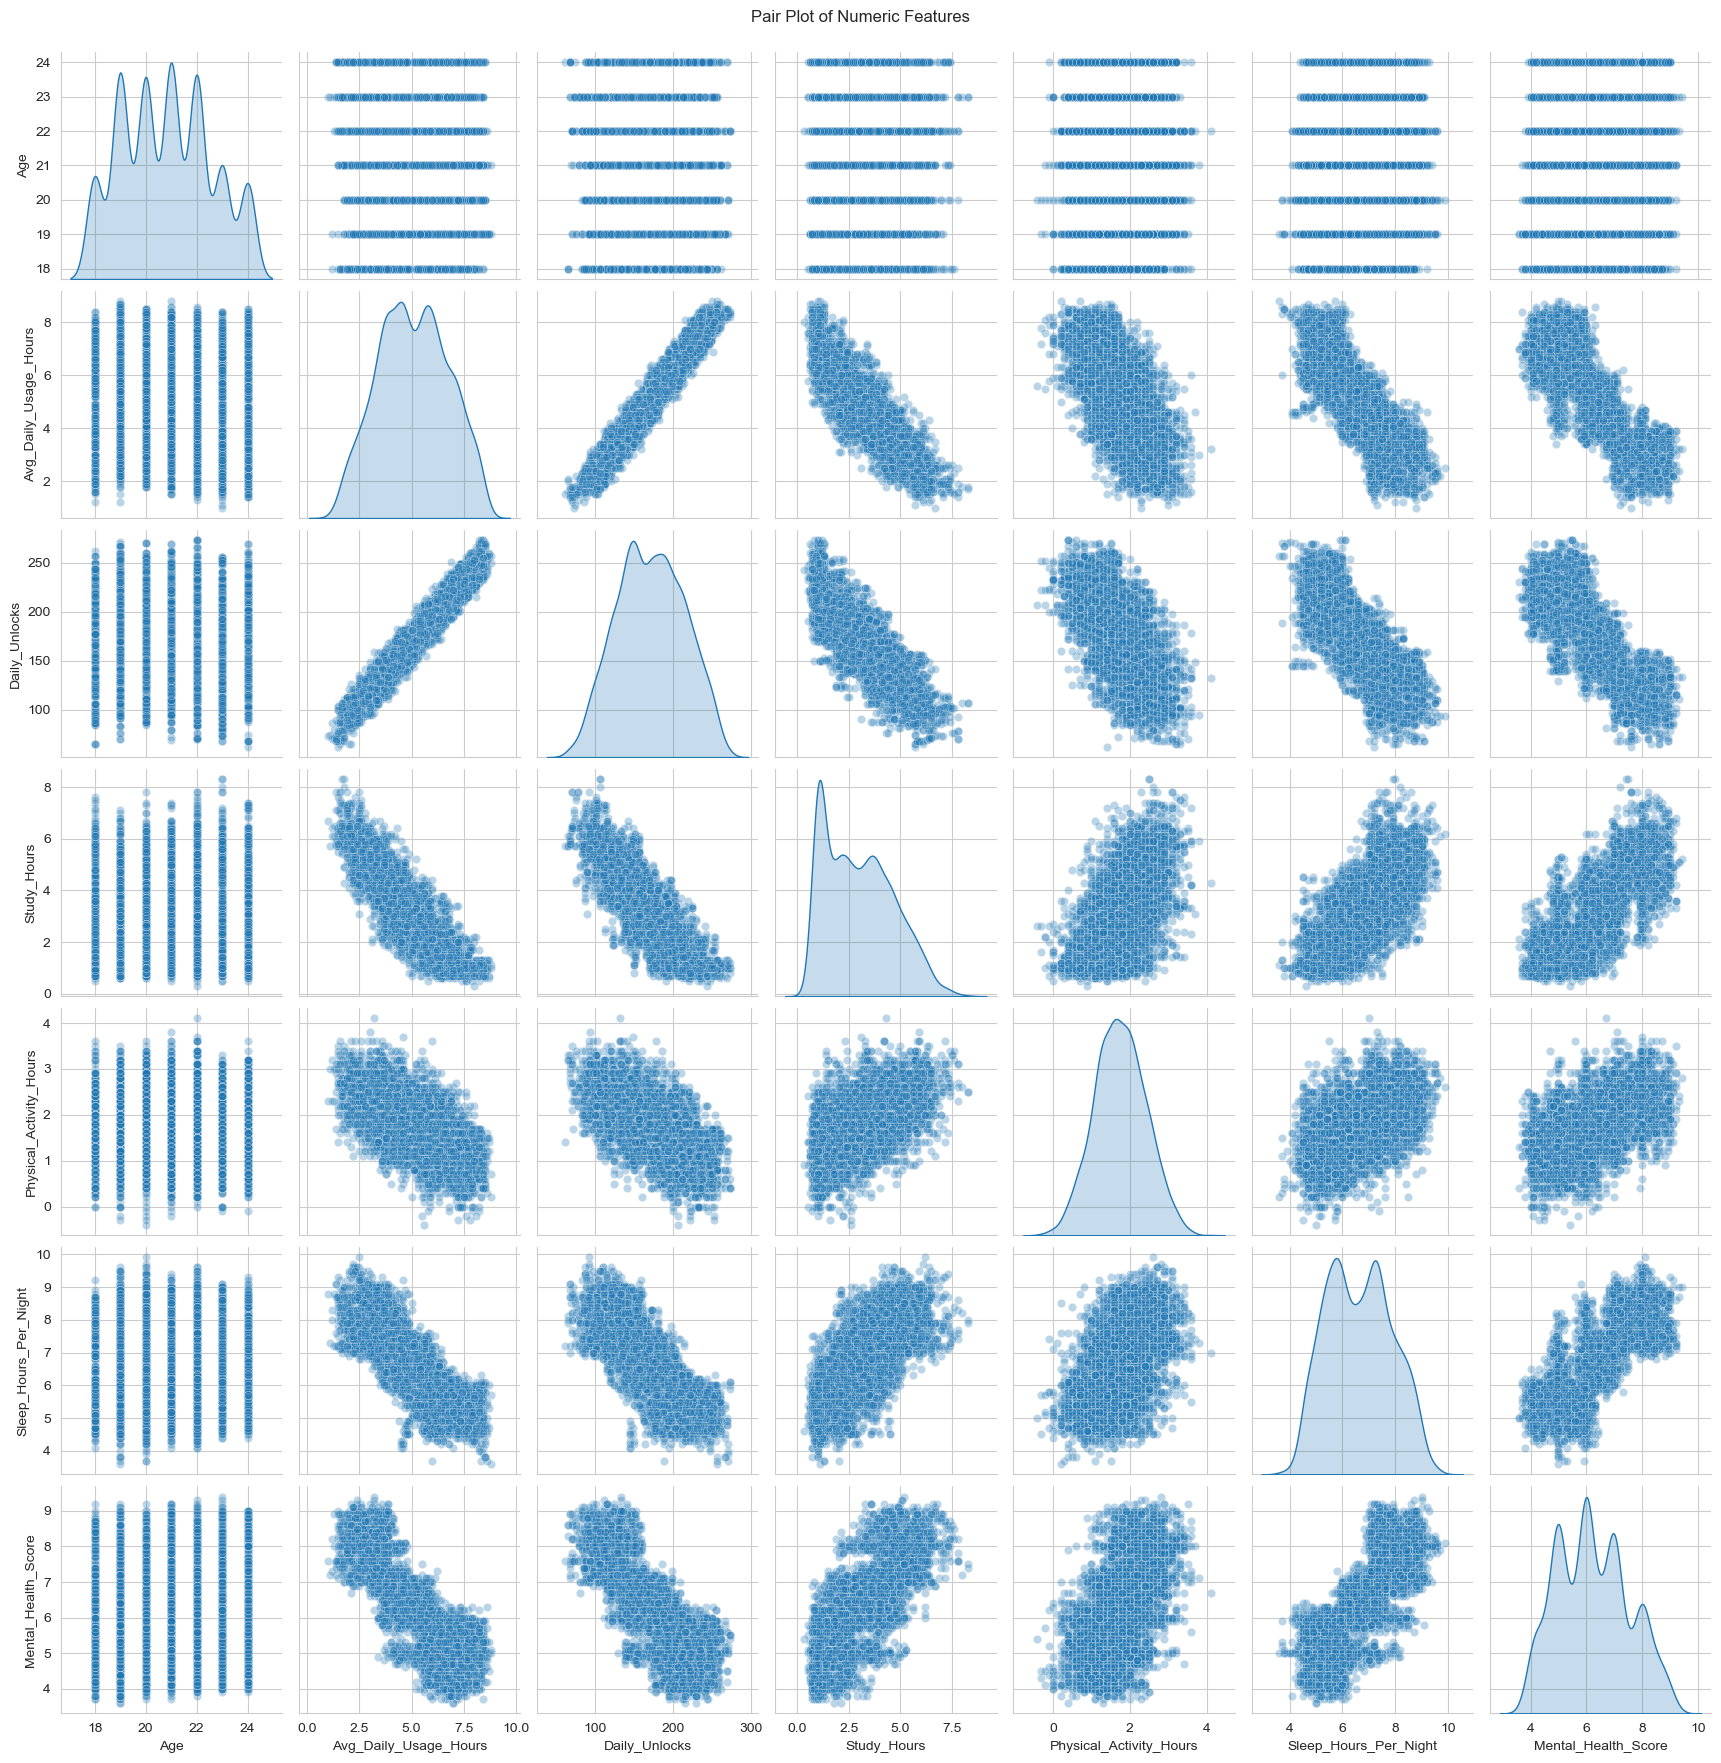

In [63]:
num_cols_plot = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks','Study_Hours', 'Physical_Activity_Hours',
                 'Sleep_Hours_Per_Night', 'Mental_Health_Score']
sns.pairplot(df[num_cols_plot], diag_kind='kde',plot_kws={'alpha':0.3})
plt.suptitle('Pair Plot of Numeric Features',y=1.01)
plt.show()

## 5. Feature Engineering : Before training, we turn categorical text into numbers using scikit-learn Pipelines
| Approach | Why | Applied to |
|---|---|---|
| **Median Imputation** | Fills any missing numeric values | All numeric columns |
| **StandardScaler** | Zero-mean, unit-variance scaling | All numeric columns |
| **Most-Frequent Imputation** | Fills any missing categorical values | All categorical columns |
| **OneHotEncoder** | Converts categories to 0/1 columns | All categorical columns |

Wrapping everything in a Pipeline guarantees the same transformations are applied to both train and test sets — preventing data leakage.

In [87]:
# ── Define target and features ───────────────────────────────────────
target_col = 'Mental_Health_Score'
x = df.drop(columns=[target_col])
y = df[target_col]

# ── Separate numeric and categorical feature names ───────────────────
numeric_cols = x.select_dtypes(include=['int64','float64']).columns.tolist()  # It gives separate numeric column
categorical_cols = x.select_dtypes(exclude=['int64','float64']).columns.tolist()  # It gives separate categorical column

print("numeric features   :",numeric_cols)
print("categorical features   :",categorical_cols)
print(f"\nTarget: {target_col}  |  range: {y.min():.1f} – {y.max():.1f}")

numeric features   : ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
categorical features   : ['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use', 'Stress_Level']

Target: Mental_Health_Score  |  range: 3.6 – 9.4


In [86]:
# ── Numeric pipeline: fill medians → scale to unit variance ─────────
numeric_transformer = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scalar',StandardScaler())
])

# ── Categorical pipeline: fill mode → one-hot encode ─────────────────
categorical_transformer = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',
                             sparse_output=False))
])

# ── Combine both into one ColumnTransformer ───────────────────────────
preprocessor = ColumnTransformer([
    ('num',numeric_transformer, numeric_cols),
    ('cat',categorical_transformer, categorical_cols)
])

print("preprocessing pipeline defined.")

preprocessing pipeline defined.


In [66]:
# ── Train / Test Split  (80 % train, 20 % test) ─────────────────────
# random_state=42 ensures the same split every time you run the notebook

x_train,x_test,y_train,y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print(f"Training set : {x_train.shape[0]:,} rows")
print(f"Test set     : {x_test.shape[0]:,} rows")

Training set : 4,000 rows
Test set     : 1,000 rows


## 6. Model Training

We train **six regression models** and compare their performance:

| # | Model | Key Idea |
|---|---|---|
| 1 | **Linear Regression** | Baseline — fits a straight hyperplane through the data |
| 2 | **Ridge Regression** | Linear + L2 penalty to reduce overfitting |
| 3 | **Decision Tree** | Non-linear tree that splits on feature thresholds |
| 4 | **Random Forest** | Ensemble of 200 decision trees — reduces variance via averaging |
| 5 | **Gradient Boosting** | Trees trained sequentially to correct previous errors |
| 6 | **Extra Trees** | Like Random Forest but with random split thresholds (faster, often just as accurate) |

Each model is wrapped in a **Pipeline** so preprocessing always runs first.

In [67]:
# ----Define all six models-------------------------
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Decision Tree':     DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=10,
                                                random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=500,
                                                    learning_rate=0.03,
                                                    max_depth=4,
                                                    subsample=0.9,
                                                    random_state=42),
    'Extra Trees':       ExtraTreesRegressor(n_estimators=200, max_depth=10,
                                              random_state=42, n_jobs=-1),
}

print(f" {len(models)} models defined and ready to train.")

 6 models defined and ready to train.


In [68]:
# ── Train every model and record test-set metrics ─────────────────────
results = {}

for name, regressor in models.items():
    # 1. Build pipeline: preprocessor → model
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor',    regressor)
    ])

    # 2. Fit on training data
    pipe.fit(x_train, y_train)

    # 3. Predict on the held-out test set
    y_pred = pipe.predict(x_test)

    # 4. Compute metrics
    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # 5. Store everything for later
    results[name] = {'pipe': pipe, 'y_pred': y_pred,
                     'R2': r2, 'MAE': mae, 'RMSE': rmse}

    print(f"{name:25s}  R² = {r2*100:.2f}%   MAE = {mae:.4f}   RMSE = {rmse:.4f}")

print("\nAll models trained!")

Linear Regression          R² = 79.34%   MAE = 0.4692   RMSE = 0.5986
Ridge Regression           R² = 79.31%   MAE = 0.4702   RMSE = 0.5989
Decision Tree              R² = 82.40%   MAE = 0.4108   RMSE = 0.5524
Random Forest              R² = 86.82%   MAE = 0.3572   RMSE = 0.4781
Gradient Boosting          R² = 87.40%   MAE = 0.3597   RMSE = 0.4675
Extra Trees                R² = 87.23%   MAE = 0.3632   RMSE = 0.4706

All models trained!


## 7. Model Evaluation

### Metrics Explained
| Metric | Formula (simplified) | Better when... |
|---|---|---|
| **R²** | 1 − (residual variance / total variance) | **Higher** (max = 1.0) |
| **MAE** | mean( |actual − predicted| ) | **Lower** |
| **RMSE** | √ mean( (actual − predicted)² ) | **Lower** (penalises large errors more than MAE) |

### 8. Summary Table

In [69]:
# ── Build summary DataFrame ───────────────────────────────────────────
summary = pd.DataFrame({
    name: {'R² (%)': round(v['R2']*100, 2),
           'MAE':    round(v['MAE'],    4),
           'RMSE':   round(v['RMSE'],   4)}
    for name, v in results.items()
}).T.sort_values('R² (%)', ascending=False)

# Highlight best scores
summary.style \
    .background_gradient(subset=['R² (%)'],      cmap='Greens') \
    .background_gradient(subset=['MAE', 'RMSE'], cmap='Reds_r') \
    .set_caption("Model Performance Comparison — Test Set")

,R² (%),MAE,RMSE
Gradient Boosting,87.400000,0.359700,0.467500
Extra Trees,87.230000,0.363200,0.470600
Random Forest,86.820000,0.357200,0.478100
Decision Tree,82.400000,0.410800,0.552400
Linear Regression,79.340000,0.469200,0.598600
Ridge Regression,79.310000,0.470200,0.598900


### 9. R² Bar Chart
Green bar = best model.

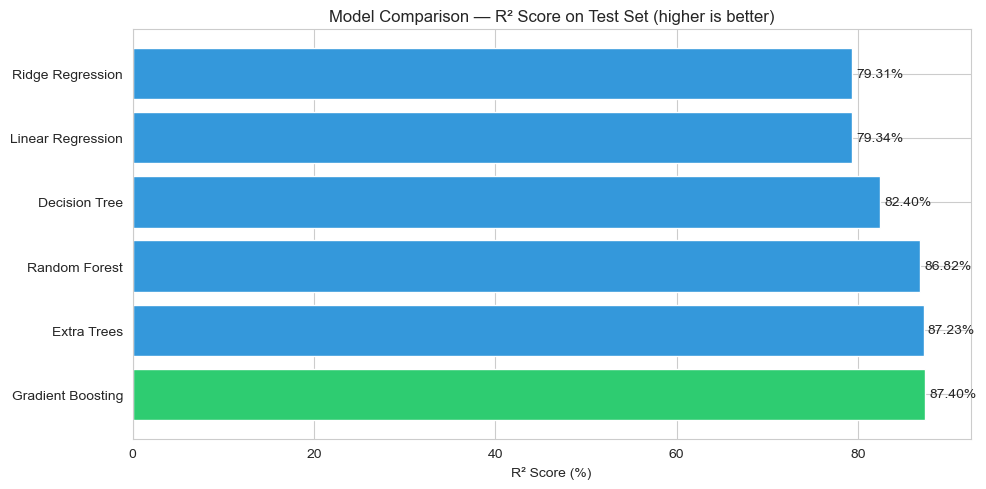

In [70]:
fig, ax = plt.subplots(figsize=(10,5))
colors = ['#2ecc71' if v == summary['R² (%)'].max()
          else '#3498db' for v in summary['R² (%)'].values]
bars = ax.barh(summary.index, summary['R² (%)'], color=colors)
ax.bar_label(bars, fmt='%.2f%%', padding=3)
ax.set_xlabel('R² Score (%)')
ax.set_title('Model Comparison — R² Score on Test Set (higher is better)')
ax.set_xlim(0, summary['R² (%)'].max() + 5)
plt.tight_layout(); plt.show()

### 10. MAE Bar Chart
Red bar = best model (lowest MAE).

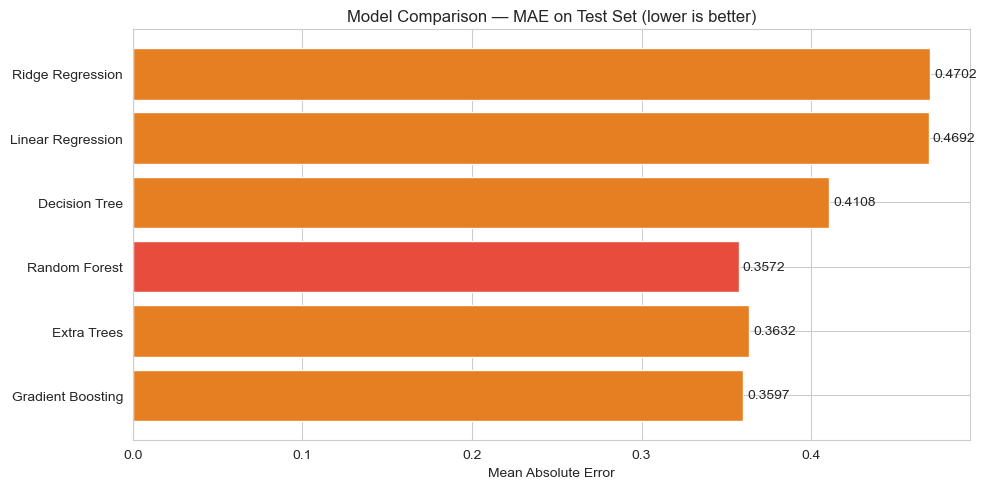

In [71]:
fig, ax = plt.subplots(figsize=(10,5))
colors = ['#e74c3c' if v == summary['MAE'].min()
          else '#e67e22' for v in summary['MAE'].values]
bars = ax.barh(summary.index, summary['MAE'], color=colors)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_xlabel('Mean Absolute Error')
ax.set_title('Model Comparison — MAE on Test Set (lower is better)')
plt.tight_layout(); plt.show()

### 11. RMSE Bar Chart

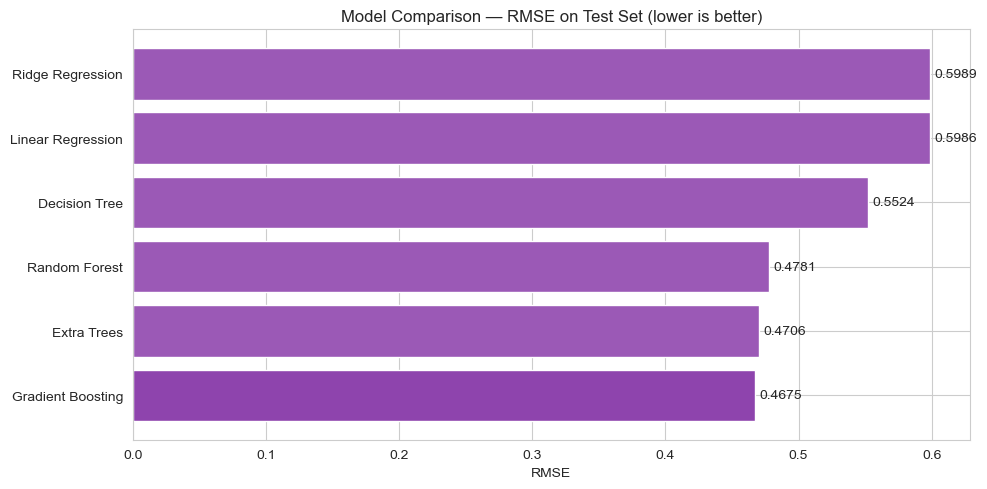

In [72]:
fig, ax = plt.subplots(figsize=(10,5))
colors = ['#8e44ad' if v == summary['RMSE'].min()
          else '#9b59b6' for v in summary['RMSE'].values]
bars = ax.barh(summary.index, summary['RMSE'], color=colors)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_xlabel('RMSE')
ax.set_title('Model Comparison — RMSE on Test Set (lower is better)')
plt.tight_layout(); plt.show()

### 12. Cross-Validation (5-Fold)
5-fold CV splits the data into 5 parts, trains on 4 and tests on 1 — repeated 5 times. This gives a more reliable performance estimate than a single split.

In [73]:
print("5-Fold Cross-Validation R² Scores:\n")
cv_results = {}

for name, regressor in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor',    regressor)
    ])
    scores = cross_val_score(pipe, x, y, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:25s}: mean = {scores.mean()*100:.2f}%   std = {scores.std()*100:.2f}%")

5-Fold Cross-Validation R² Scores:

  Linear Regression        : mean = 77.92%   std = 1.46%
  Ridge Regression         : mean = 77.91%   std = 1.48%
  Decision Tree            : mean = 81.43%   std = 2.16%
  Random Forest            : mean = 86.49%   std = 2.22%
  Gradient Boosting        : mean = 86.91%   std = 2.38%
  Extra Trees              : mean = 87.08%   std = 1.63%


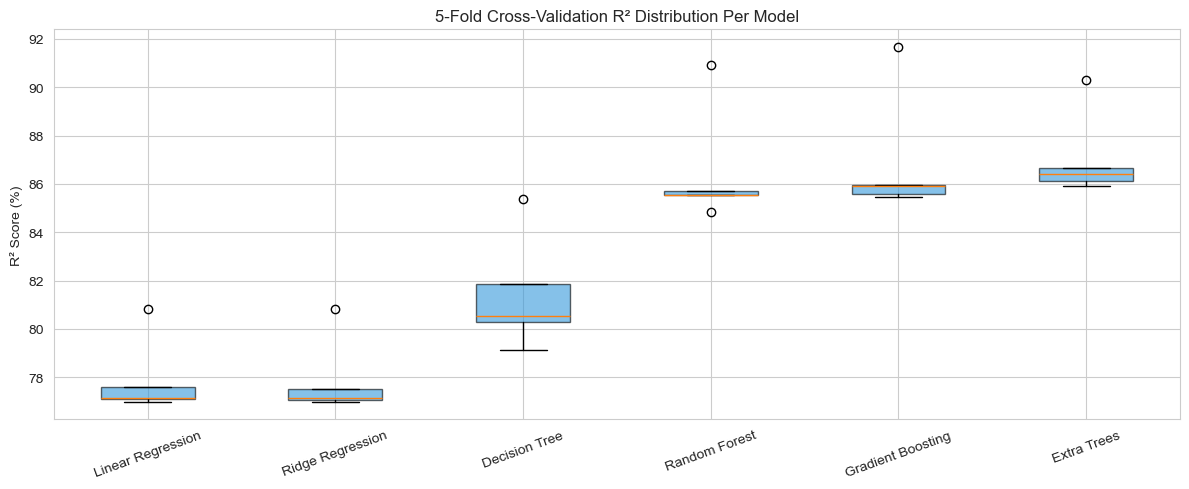

In [74]:
# ── Box plot of CV distributions ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12,5))
ax.boxplot(
    [cv_results[n]*100 for n in cv_results],
    labels=list(cv_results.keys()),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.6)
)
ax.set_ylabel('R² Score (%)')
ax.set_title('5-Fold Cross-Validation R² Distribution Per Model')
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

## 13. Best Model Deep-Dive

We automatically identify the best-performing model (highest R²) and inspect it in detail.

In [75]:
# ── Identify best model automatically ─────────────────────────────────
best_name = summary['R² (%)'].idxmax()
best      = results[best_name]

print(f" Best model : {best_name}")
print(f"    R²        = {best['R2']*100:.2f}%")
print(f"    MAE       = {best['MAE']:.4f}")
print(f"    RMSE      = {best['RMSE']:.4f}")

 Best model : Gradient Boosting
    R²        = 87.40%
    MAE       = 0.3597
    RMSE      = 0.4675


## 💾 Save Final Model for Streamlit Deployment

In [76]:
import joblib

final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', models[best_name])
])

final_model.fit(x, y)

joblib.dump(final_model, "student_mental_health_model.joblib")

print("✅ Final model saved as 'student_mental_health_model.joblib'")

✅ Final model saved as 'student_mental_health_model.joblib'


### 14. Actual vs Predicted
Ideally, all points lie on the red dashed diagonal (perfect prediction). Spread around the line reveals the model's uncertainty.

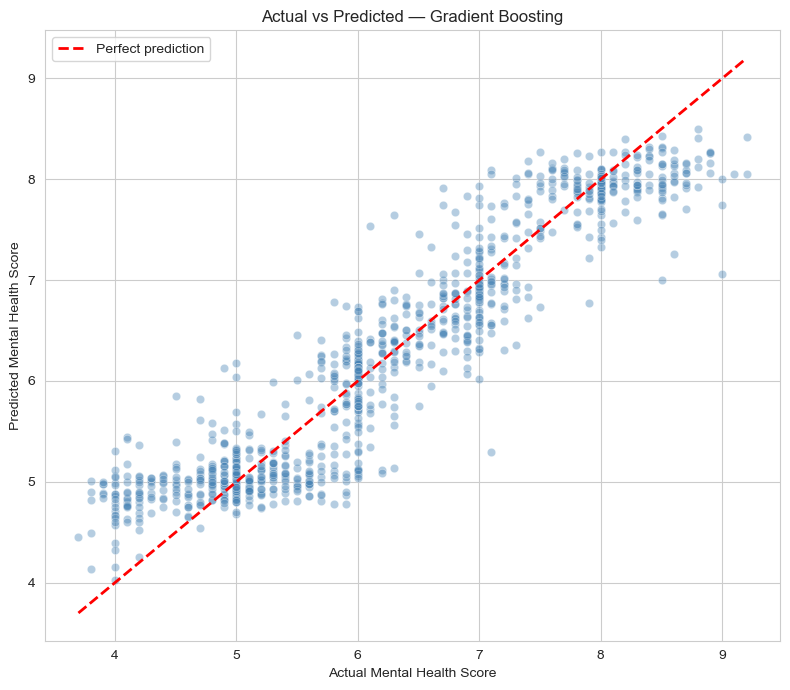

In [77]:
y_pred_best = best['y_pred']

plt.figure(figsize=(8,7))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.4, color='steelblue')
lo, hi = y_test.min(), y_test.max()
plt.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Mental Health Score')
plt.ylabel('Predicted Mental Health Score')
plt.title(f'Actual vs Predicted — {best_name}')
plt.legend(); plt.tight_layout(); plt.show()

### 15. Residuals Analysis
**Residuals** = Actual − Predicted. A random scatter around zero is ideal. Patterns indicate systematic bias.

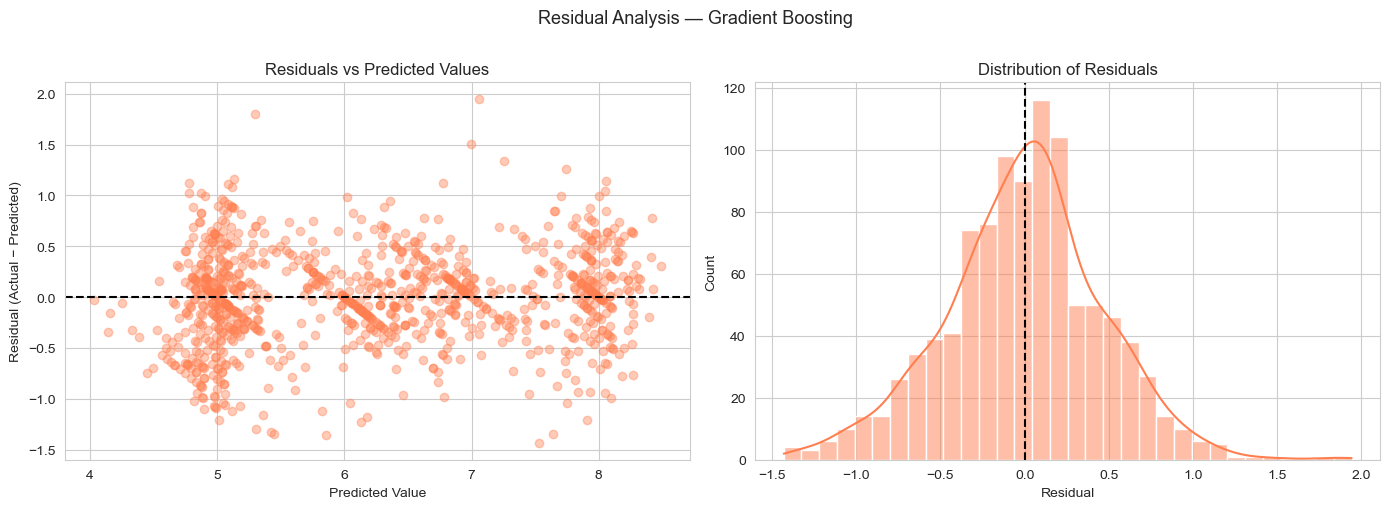

Mean of residuals : -0.0063  (ideally 0)
Std  of residuals : 0.4675


In [78]:
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Residuals vs Predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.4, color='coral')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_xlabel('Predicted Value')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residuals vs Predicted Values')

# Right: Residual distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='coral')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_title('Distribution of Residuals')

plt.suptitle(f'Residual Analysis — {best_name}', y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

print(f"Mean of residuals : {residuals.mean():.4f}  (ideally 0)")
print(f"Std  of residuals : {residuals.std():.4f}")

### 16. Feature Importance
For tree-based models, `.feature_importances_` shows which features drove the most splits — i.e., which features the model relied on most.

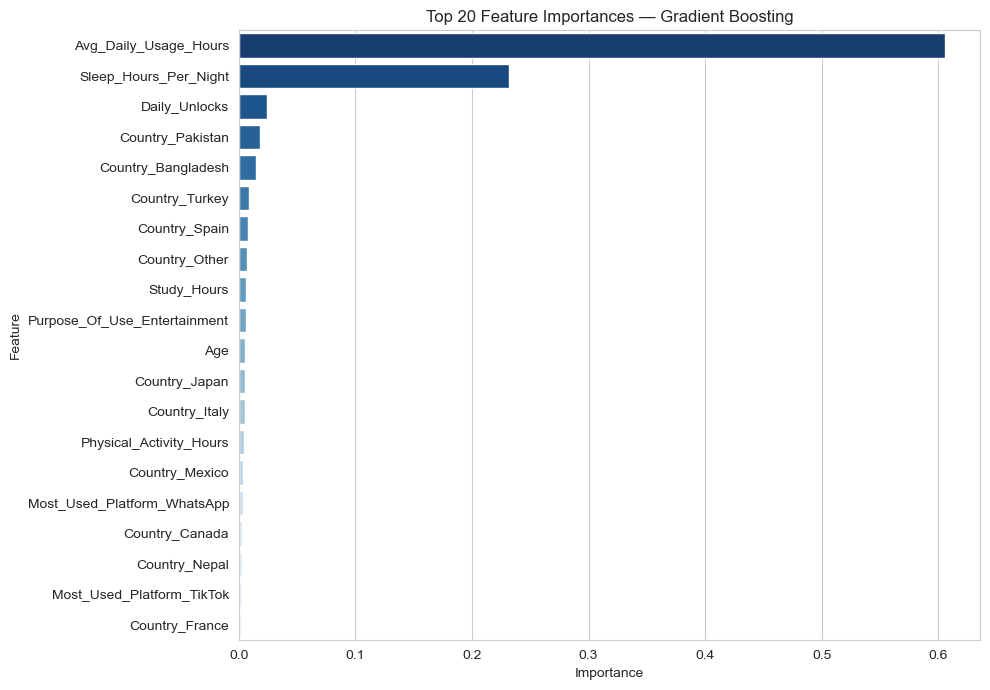

In [79]:
best_regressor = best['pipe'].named_steps['regressor']

if hasattr(best_regressor, 'feature_importances_'):
    # Recover feature names produced by OneHotEncoder
    ohe_names = (best['pipe']
                 .named_steps['preprocessor']
                 .named_transformers_['cat']
                 .named_steps['encoder']
                 .get_feature_names_out(categorical_cols)
                 .tolist())
    all_names    = numeric_cols + ohe_names
    importances  = best_regressor.feature_importances_

    fi_df = (pd.DataFrame({'Feature': all_names, 'Importance': importances})
             .sort_values('Importance', ascending=False)
             .head(20))

    plt.figure(figsize=(10, 7))
    sns.barplot(data=fi_df, y='Feature', x='Importance', palette='Blues_r')
    plt.title(f'Top 20 Feature Importances — {best_name}')
    plt.tight_layout(); plt.show()

elif hasattr(best_regressor, 'coef_'):
    # Linear models use coefficients instead
    ohe_names = (best['pipe']
                 .named_steps['preprocessor']
                 .named_transformers_['cat']
                 .named_steps['encoder']
                 .get_feature_names_out(categorical_cols)
                 .tolist())
    all_names = numeric_cols + ohe_names
    coef      = best_regressor.coef_
    coef_df   = (pd.DataFrame({'Feature': all_names, 'Coefficient': coef})
                 .reindex(np.argsort(np.abs(coef))[::-1])
                 .head(20))
    plt.figure(figsize=(10,7))
    sns.barplot(data=coef_df, y='Feature', x='Coefficient', palette='coolwarm')
    plt.title(f'Top 20 Feature Coefficients — {best_name}')
    plt.tight_layout(); plt.show()

## 17. Final Summary

In [80]:
print("=" * 62)
print(f"  {'Model':<25} {'R² (%)':>8} {'MAE':>8} {'RMSE':>8}")
print("=" * 62)
for row in summary.itertuples():
    marker = "  🏆" if row.Index == best_name else ""
    print(f"  {row.Index:<25} {row._1:>8.2f} {row.MAE:>8.4f} {row.RMSE:>8.4f}{marker}")
print("=" * 62)

  Model                       R² (%)      MAE     RMSE
  Gradient Boosting            87.40   0.3597   0.4675  🏆
  Extra Trees                  87.23   0.3632   0.4706
  Random Forest                86.82   0.3572   0.4781
  Decision Tree                82.40   0.4108   0.5524
  Linear Regression            79.34   0.4692   0.5986
  Ridge Regression             79.31   0.4702   0.5989


In [81]:
import sklearn
print(sklearn.__version__)

1.7.2


### 🔑 Key Findings

1. **Stress Level** is the strongest predictor of Mental Health Score — confirmed by both EDA boxplots and feature importance.
2. **Sleep Hours** shows a positive correlation — students who sleep more tend to score higher.
3. **Physical Activity** also positively correlates with mental health scores.
4. **Social Media Usage** has a mild negative association — heavy users tend to be in higher stress groups.
5. **Platform & Purpose** make smaller but measurable differences, visible in the EDA boxplots.

### 🚀 Possible Next Steps
- **Hyperparameter Tuning** — use `GridSearchCV` or `RandomizedSearchCV` on the best model
- **Classification Version** — predict `Stress_Level` (Low / Medium / High / Very High)